In [3]:
import pandas as pd
import seaborn as sns

In [6]:
house_data = pd.read_csv("HousePricePrediction.csv")

In [50]:
house_data.shape
house_data.head()
house_data.info()
house_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2913 entries, 0 to 2918
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MSSubClass           2913 non-null   int64  
 1   LotArea              2913 non-null   int64  
 2   OverallCond          2913 non-null   int64  
 3   YearBuilt            2913 non-null   int64  
 4   YearRemodAdd         2913 non-null   int64  
 5   BsmtFinSF2           2913 non-null   float64
 6   TotalBsmtSF          2913 non-null   float64
 7   SalePrice            2913 non-null   float64
 8   MSZoning_FV          2913 non-null   bool   
 9   MSZoning_RH          2913 non-null   bool   
 10  MSZoning_RL          2913 non-null   bool   
 11  MSZoning_RM          2913 non-null   bool   
 12  LotConfig_CulDSac    2913 non-null   bool   
 13  LotConfig_FR2        2913 non-null   bool   
 14  LotConfig_FR3        2913 non-null   bool   
 15  LotConfig_Inside     2913 non-null   bool  

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2913.000000,2913.000000,2913.000000,2913.000000,2913.000000,2913.000000,2913.000000,2913.000000
mean,57.190182,10137.665980,5.566770,1971.391349,1984.314452,49.667353,1052.805012,180921.195890
std,42.538067,7832.598853,1.108977,30.258751,20.864950,169.338330,439.688510,56232.174632
min,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,20.000000,7476.000000,5.000000,1954.000000,1965.000000,0.000000,793.000000,163000.000000
50%,50.000000,9450.000000,5.000000,1973.000000,1993.000000,0.000000,990.000000,180921.195890
75%,70.000000,11553.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,180921.195890
max,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [51]:
house_data.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,MSZoning_RH,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,False,False,...,False,False,False,False,False,False,False,True,False,False
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,60,11250,5,2001,2002,0.0,920.0,223500.0,False,False,...,False,False,False,False,False,False,False,True,False,False
3,70,9550,5,1915,1970,0.0,756.0,140000.0,False,False,...,False,False,False,False,False,False,False,False,True,False
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,False,False,...,False,False,False,False,False,False,False,True,False,False


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

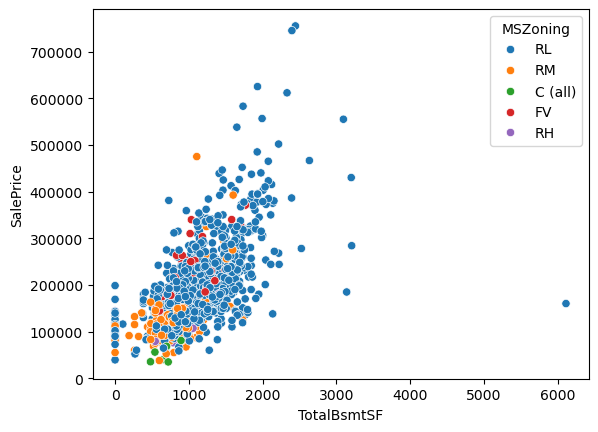

In [12]:
#visulalize
sns.scatterplot(x=house_data["TotalBsmtSF"] , y = house_data["SalePrice"],hue=house_data["MSZoning"])

In [33]:
#preprocessiing
house_data.drop(['Id'],
                axis=1,inplace=True)
# Replacing SalePrice empty values with their mean values
house_data['SalePrice'] = house_data['SalePrice'].fillna( house_data['SalePrice'].mean())
# Drop records with null values
house_data = house_data.dropna()

house_data.isnull().sum()
house_data.head()


,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [36]:
#removing few data and then visualizing 
#preprocessing here not required
# Data Preprocessing - Encoding (Covered in Supervised ML Part2)
cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
house_data = pd.get_dummies(house_data , columns=cols,drop_first=True)

In [40]:
#Train test -split ( 80:20)
from sklearn.model_selection import train_test_split

X = house_data.drop(['SalePrice'] , axis=1)
y = house_data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [41]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
2356,20,7441,5,2006,2006,0.0,1461.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1789,30,10800,5,1890,1998,0.0,630.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2371,20,7321,5,1999,2000,0.0,1339.0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
930,20,8925,5,2007,2007,0.0,1466.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2816,20,13050,6,1963,1963,850.0,1000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [42]:
#Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = model.predict(X_test)


In [45]:
y_test

178     501837.00000
678     372500.00000
2878    180921.19589
2691    180921.19589
1898    180921.19589
            ...     
1221    134000.00000
542     213250.00000
2319    180921.19589
1644    180921.19589
1591    180921.19589
Name: SalePrice, Length: 583, dtype: float64

In [46]:
X_test.shape

(583, 33)

In [47]:
#model evaluation
from sklearn.metrics import mean_absolute_error,r2_score , mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
#y_pred = model.predict(X_test) already rpediction line done

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))


R2 Score: 0.3469223785187565
MAE: 32690.891525374333
RMSE: 48797.194708473995
0.20016996577116697


In [48]:
# Feature Scaling - to try & improve baseline performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

# To get better results we can try some other regression model 
# & also use techniques like Bagging & Boosting (will cover later).

R2 Score: 0.3469223785187556
MAE: 32690.891525374333
RMSE: 48797.194708474024
0.20016996577116697
